In [4]:
pip install -r requirements.txt

ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'
Note: you may need to restart the kernel to use updated packages.


In [4]:
#import utils.gcp_handling
import utils.components as components
import utils.train_helper as train_helper
import os
# Import necessary libraries
from kfp.v2 import dsl
from kfp.v2.dsl import component
from kfp.v2 import compiler

from google.cloud import aiplatform

In [5]:
user_constants = {
    "EMAIL": "palmere1_aetna_com", # e.g., john.doe@cvshealth.com
    "COSTCENTER": "13070", # Insert your costcenter here
    "TENANT": "hcm-cm-de", # e.g., mleng-platform
    "USE_COMPUTE_PROJECT": True, # e.g., True or False
    "OWNER": "palmere1_aetna_com",
    "COMPUTE_PROJECT": "anbc-dev-hcm-cm-de",
    "PROJECT": "anbc-dev-hcm-cm-de",
    'LABELS': {'owner': 'palmere1_aetna_com',
            'costcenter': '13070',
            'tenant': 'hcm-cm-de',
            'self_serve': 'true',
            'lob': 'hcb',
            'pipeline_type': 'training_prediction'},
    # 'hcb' or 'pss' or 'ent'
    "LOB": "hcb",
    "DOCKER_URI": "us-docker.pkg.dev/vertex-ai/training/xgboost-gpu.2-1:latest",
    "SERVICE_ACCOUNT": "gchcb-hcm-cm-de-ontpd@anbc-dev-hcm-cm-de.iam.gserviceaccount.com",
    "SERVICE_ACCOUNT_COMPUTE_PROJECT": None,  # Add this key
    "CMEK_KEY": "projects/cvs-key-vault-nonprod/locations/us-east4/keyRings/gkr-nonprod-us-east4/cryptoKeys/gk-anbc-dev-hcm-cm-de-us-east4",
    "CMEK_KEY_COMPUTE_PROJECT": None,  # Add this key
    "COMPUTE_PROJECT": None,  # Add this key
    "SHARED_PROJECT": "anbc-hcb-dev",
    "LOCATION": "us-east4",
    # save_location -> may be helpful for tracking artifacts / model registration etc
    # 'MANUAL_SAVE_LOCATION': 'gs://',
    # name of this repo
    # If defined, overwrites system-derived REPO_NAME value
    "MODEL_DESCRIPTION": "demo_maternity_fe", # Description for model when registered with ML Platform
    "PIPELINE_TYPE": "training_prediction", # Supported values: training, prediction, evaluation, training_prediction, other
    
    # SQL Variables for BigQuery queries
    "GCP_PROJECT": "anbc-hcb-dev",
    "GCP_DB": "cm_medicaid_hcb_dev", 
    "PREFIX": "a534354_mlops_demo",
    "DEFAULT_EXP": "INTERVAL 20 DAY",
    "ST": "{GCP_PROJECT}.{GCP_DB}.{PREFIX}_st",
    "SDOH_YEAR":'2024',
    'JOB_CONFIG': {'cost_center': '13070',
                'email': 'palmere1_aetna_com',
                'project': 'anbc-dev-hcm-cm-de',
                'bq_job_labels': {'self_serve': 'true',
                                  'model_name': 'didactic-broccoli-hcm-cm-de-model',
                                  'pipeline_type': 'training_prediction',
                                  'vertex-ai-pipelines-run-billing-id': 'none'},
                'bq_table_labels': {'self_serve': 'true',
                                    'model_name': 'didactic-broccoli-hcm-cm-de-model',
                                    'pipeline_type': 'training_prediction',
                                    'vertex-ai-pipelines-run-billing-id': 'none'}}
}

In [7]:
constants = user_constants
os.environ["OWNER"] = constants["EMAIL"]
os.environ["COSTCENTER"] = constants["COSTCENTER"]

# File from Bucket

In [9]:
from google_cloud_pipeline_components.preview import (
    custom_job as persistent_job,
    dataflow as dataflow_flex,
    llm,
)
from google_cloud_pipeline_components.v1 import (
    bigquery,
    custom_job,
)
from typing import Any, Dict, List, Optional
def required_kf_info(constants: dict) -> List[str]:
    """A helper function to get the correct project / label / save location"""

    project = compute_project_handler(constants)
    service_account = (
        constants["SERVICE_ACCOUNT_COMPUTE_PROJECT"]
        if constants["SERVICE_ACCOUNT_COMPUTE_PROJECT"]
        else constants["SERVICE_ACCOUNT"]
    )
    cmek_key = (
        constants["CMEK_KEY_COMPUTE_PROJECT"]
        if constants["CMEK_KEY_COMPUTE_PROJECT"]
        else constants["CMEK_KEY"]
    )
    # ai_platform_loc = pipeline_root  # os.getenv('AIP_MODEL_DIR', pipeline_root)

    return project, service_account, cmek_key  # , ai_platform_loc
def compute_project_handler(constants):
    """Reused utility to get the correct project"""

    default_project = os.getenv("CLOUD_ML_PROJECT_ID", constants["PROJECT"])
    project = constants["COMPUTE_PROJECT"] or default_project

    return project
def customjob_component_with_gcs_download(
    pipeline_root: str,
    constants: dict,
    machine_type: dict,
    file_to_run: str,
    display_name: str,
    packages: Optional[List[str]] = None,
    env: Optional[dict] = None,
    args: Optional[List[str]] = None,
    persistent_resource_id: Optional[str] = None,
) -> dsl.component:
    """Modified to handle GCS paths"""
    
    project, service_account, cmek_key = required_kf_info(constants)
    ENV = generate_compute_environment(pipeline_root, constants, env)

    # Check if file_to_run is a GCS path
    if file_to_run.startswith('gs://'):
        filename = file_to_run.split('/')[-1]
        
        # Build package installation command
        if packages:
            # Join packages with spaces - versions are preserved if specified
            packages_str = " ".join(packages)
            packages_install = f"pip install --root-user-action=ignore {packages_str}"
        else:
            packages_install = ""

        # Build the complete command with verification
        if packages_install:
            # Install packages, verify critical versions, then run script
            command = [
                "bash", "-c", 
                f"{packages_install} && "
                f"pip list && "
                f"gsutil cp {file_to_run} ./{filename} && "
                f"python3 {filename}"
            ]
        else:
            # No packages to install, just download and run
            command = [
                "bash", "-c",
                f"gsutil cp {file_to_run} ./{filename} && python3 {filename}"
            ]
    else:
        command = ["python3", file_to_run]


    kwargs = {
        "project": str(project),
        "display_name": display_name,
        "location": constants["LOCATION"],
        "worker_pool_specs": [
            {
                "machineSpec": {**machine_type},
                "replicaCount": "1",
                "containerSpec": {
                    "imageUri": constants["DOCKER_URI"],
                    "command": command,
                    "env": ENV,
                    "args": args or [],
                },
            }
        ],
        "labels": constants["LABELS"],
        "base_output_directory": os.getenv("AIP_MODEL_DIR", pipeline_root),
    }

    if persistent_resource_id:
        disk_spec = {
            "disk_spec": {
                "bootDiskType": "pd-standard",
                "bootDiskSizeGb": 200,
            }
        }
        kwargs["worker_pool_specs"].update(disk_spec)
        custom_job_component = persistent_job.CustomTrainingJobOp(
            persistent_resource_id=persistent_resource_id,
            timeout="2700000s",
            **kwargs,
        )
    else:
        custom_job_component = custom_job.CustomTrainingJobOp(
            service_account=service_account, 
            encryption_spec_key_name=cmek_key, 
            **kwargs
        )

    custom_job_component.set_display_name(display_name)
    return custom_job_component
    
def generate_compute_environment(pipeline_root: str, constants: dict, env: dict = None):

    base_env = {
        "PYTHONPATH": "$PYTHONPATH:/home/jupyter/my_repo/:/home/jupyter/builtin_scripts",
        "LOB": constants["LOB"],
        "PROJECT": constants["PROJECT"],
        "COMPUTE_PROJECT": constants["COMPUTE_PROJECT"] or "False",
        "SHARED_PROJECT": constants["SHARED_PROJECT"],
        "AIP_DIR": pipeline_root,
        **keymap(lambda k: k.upper(), constants["LABELS"]),
    }

    env = env or {}
    final_env = merge(base_env, env)
    final_env = [{"name": k, "value": str(v)} for k, v in final_env.items() if v]

    return final_env

In [5]:
#constants["DOCKER_URI"] =  "us-docker.pkg.dev/vertex-ai/training/xgboost-gpu.2-1:latest"
constants["DOCKER_URI"] =  "us-docker.pkg.dev/vertex-ai/training/xgboost-cpu.2-1:latest"

In [ ]:
from google.cloud import aiplatform
import os
import kfp.dsl as dsl
from kfp import compiler
from time import time
from cytoolz.curried import merge, keymap
# Define the pipeline
@dsl.pipeline(
    name="maternity-demo-fe-pipeline",
    description="Pipeline to run feature engineering script using XGBoost GPU image"
)

def feature_engineering_pipeline(
    project_id: str = "anbc-dev-hcm-cm-de",
    region: str = "us-east4",
    cmek_key: str = "projects/cvs-key-vault-nonprod/locations/us-east4/keyRings/gkr-nonprod-us-east4/cryptoKeys/gk-anbc-dev-hcm-cm-de-us-east4",
    pipeline_root: str = "gs://hcm-cm-de-code-hcb-dev/vertex-test/",
    file_to_run: str = "feature-engineering.py"
):
    
    # This is the body of the pipeline
    # Use .after(component) to set flow of individual components
    # Use .after(*[component1, component2, componentN]) for setting after multiple components

    #################################
    # Feature Engineering Pipeline
    #################################

    # Set up environment variables
    env = {
        "GOOGLE_CLOUD_PROJECT": "anbc-dev-hcm-cm-de",
        "GCP_PROJECT": "anbc-dev-hcm-cm-de",  # Add this
    }
    
    machine_type = {
        "machineType": "n1-standard-64",
        #"acceleratorType": "NVIDIA_TESLA_P4",   # or NVIDIA_TESLA_A100, NVIDIA_TESLA_V100
        #"acceleratorCount": 1
    }
    packages_to_install = [
    "google-cloud-bigquery",
    "google-cloud-bigquery-storage",
    "google-cloud-aiplatform", 
    "pandas",
    "numpy==1.26.4",              
    "xgboost==2.1.4",             
    "scikit-learn==1.5.2",        
    "scipy==1.15.3",              
    "joblib==1.4.2",
    "shap==0.44.1",
    "imbalanced-learn",
    "optuna",
    "cytoolz",
    "db-dtypes",
    "matplotlib",
    "seaborn", 
    "tqdm",
    "pandas_gbq"
    ]
    # Step 1: Run Feature Engineering Script using XGBoost GPU image
    feature_engineering_job = customjob_component_with_gcs_download(
        pipeline_root,
        constants,
        machine_type,
        'gs://hcm-cm-de-code-hcb-dev/vertex-test/codecode/feature-engineering.py',
        display_name="customjob-train",
        packages=packages_to_install,
        env=env,
    )

# Compile the pipeline
if __name__ == "__main__":
    compiler.Compiler().compile(
        pipeline_func=feature_engineering_pipeline,
        package_path="feature_engineering_pipeline.json"
    )

    # Initialize Vertex AI client
    aiplatform.init(
        project="anbc-dev-hcm-cm-de",
        location="us-east4",
    )

    # Define the pipeline job
    pipeline_job = aiplatform.PipelineJob(
        display_name="maternity-demo-fe-pipeline",
        template_path="feature_engineering_pipeline.json",
        pipeline_root="gs://hcm-cm-de-code-hcb-dev/vertex-test/",
        enable_caching=False,
        encryption_spec_key_name="projects/cvs-key-vault-nonprod/locations/us-east4/keyRings/gkr-nonprod-us-east4/cryptoKeys/gk-anbc-dev-hcm-cm-de-us-east4",
        parameter_values={
            "project_id": "anbc-dev-hcm-cm-de",
            "region": "us-east4",
            "cmek_key": "projects/cvs-key-vault-nonprod/locations/us-east4/keyRings/gkr-nonprod-us-east4/cryptoKeys/gk-anbc-dev-hcm-cm-de-us-east4",
            "pipeline_root": "gs://hcm-cm-de-code-hcb-dev/vertex-test/",
            "file_to_run": "feature-engineering.py"
        },
        labels={
            "owner": "palmere1_aetna_com",
            "pipeline_type": "feature_engineering",
            "lob": "hcb",
            "costcenter": "13070",
            "tenant": "hcm-cm-de",
            "self_serve": "true"
        }
    )

    # Submit the pipeline job
    pipeline_job.run(
        service_account="gchcb-hcm-cm-de-ontpd@anbc-dev-hcm-cm-de.iam.gserviceaccount.com",
        sync=True
    )

Creating PipelineJob
PipelineJob created. Resource name: projects/46378383599/locations/us-east4/pipelineJobs/maternity-demo-fe-pipeline-20260203165301
To use this PipelineJob in another session:
pipeline_job = aiplatform.PipelineJob.get('projects/46378383599/locations/us-east4/pipelineJobs/maternity-demo-fe-pipeline-20260203165301')
View Pipeline Job:
https://console.cloud.google.com/vertex-ai/locations/us-east4/pipelines/runs/maternity-demo-fe-pipeline-20260203165301?project=46378383599
PipelineJob projects/46378383599/locations/us-east4/pipelineJobs/maternity-demo-fe-pipeline-20260203165301 current state:
3
PipelineJob projects/46378383599/locations/us-east4/pipelineJobs/maternity-demo-fe-pipeline-20260203165301 current state:
3
PipelineJob projects/46378383599/locations/us-east4/pipelineJobs/maternity-demo-fe-pipeline-20260203165301 current state:
3
PipelineJob projects/46378383599/locations/us-east4/pipelineJobs/maternity-demo-fe-pipeline-20260203165301 current state:
3


# File with Base64

In [10]:
def customjob_component_with_embedded_file(
    pipeline_root: str,
    constants: dict,
    machine_type: dict,
    file_to_run: str,  # Can be local file path, GCS path, or base64 encoded content
    display_name: str,
    packages: Optional[List[str]] = None,
    env: Optional[dict] = None,
    args: Optional[List[str]] = None,
    persistent_resource_id: Optional[str] = None,
) -> dsl.component:
    """
    Modified to handle embedded files or GCS paths.
    file_to_run can be:
    - A local file path (string, compile-time): will be read and embedded
    - A GCS path (string starting with gs://): will be downloaded at runtime
    - Base64 encoded content (string): will be embedded directly
    - Pipeline parameter: will be handled at runtime (assumed to be base64 or GCS path)
    """
    import base64
    import os
    
    project, service_account, cmek_key = required_kf_info(constants)
    ENV = generate_compute_environment(pipeline_root, constants, env)
    
    # Check if file_to_run is a string (compile-time constant) or pipeline parameter
    is_string = isinstance(file_to_run, str)
    
    # Build package installation command
    if packages:
        packages_str = " ".join(packages)
        packages_install = f"pip install --root-user-action=ignore {packages_str}"
    else:
        packages_install = ""
    
    if is_string:
        # Check if it's base64 encoded content (long string, no path-like structure)
        if len(file_to_run) > 1000 and '/' not in file_to_run and '\\' not in file_to_run and not file_to_run.startswith('gs://'):
            # Likely base64 encoded content - use it directly
            ENV.append({"name": "TASK_FILE_CONTENT", "value": file_to_run})
            filename = "feature-engineering.py"
            file_setup_cmd = f"echo $TASK_FILE_CONTENT | base64 -d > ./{filename}"
        elif file_to_run.startswith('gs://'):
            # GCS path - download at runtime
            filename = file_to_run.split('/')[-1]
            file_setup_cmd = f"gsutil cp {file_to_run} ./{filename}"
        else:
            # Local file path - read and embed at compile time
            if not os.path.exists(file_to_run):
                raise FileNotFoundError(f"File not found: {file_to_run}")
            
            filename = os.path.basename(file_to_run)
            with open(file_to_run, 'rb') as f:
                file_content = f.read()
            encoded_content = base64.b64encode(file_content).decode('utf-8')
            
            ENV.append({"name": "TASK_FILE_CONTENT", "value": encoded_content})
            file_setup_cmd = f"echo $TASK_FILE_CONTENT | base64 -d > ./{filename}"
    else:
        # Pipeline parameter - handle at runtime
        ENV.append({"name": "TASK_FILE_CONTENT", "value": file_to_run})
        filename = "feature-engineering.py"
        # Check if it's GCS or base64 content at runtime
        file_setup_cmd = (
            f"if echo \"$TASK_FILE_CONTENT\" | grep -q '^gs://'; then "
            f"gsutil cp $TASK_FILE_CONTENT ./{filename}; "
            f"else "
            f"echo $TASK_FILE_CONTENT | base64 -d > ./{filename}; "
            f"fi"
        )
    
    # Combine installation and file setup commands
    if packages_install:
        install_cmd = packages_install
    else:
        install_cmd = "pip list"
    
    # Create command that installs packages, sets up file, and runs it
    command = [
        "bash", "-c",
        f"{install_cmd} && pip install --root-user-action=ignore scikit-learn==1.3.2 --upgrade && "
        f"{file_setup_cmd} && "
        f"python3 {filename}"
    ]
    
    kwargs = {
        "project": str(project),
        "display_name": display_name,
        "location": constants["LOCATION"],
        "worker_pool_specs": [
            {
                "machineSpec": {**machine_type},
                "replicaCount": "1",
                "containerSpec": {
                    "imageUri": constants["DOCKER_URI"],
                    "command": command,
                    "env": ENV,
                    "args": args or [],
                },
            }
        ],
        "labels": constants["LABELS"],
        "base_output_directory": os.getenv("AIP_MODEL_DIR", pipeline_root),
    }
    
    if persistent_resource_id:
        disk_spec = {
            "disk_spec": {
                "bootDiskType": "pd-standard",
                "bootDiskSizeGb": 200,
            }
        }
        kwargs["worker_pool_specs"][0].update(disk_spec)
        custom_job_component = persistent_job.CustomTrainingJobOp(
            persistent_resource_id=persistent_resource_id,
            timeout="2700000s",
            **kwargs,
        )
    else:
        custom_job_component = custom_job.CustomTrainingJobOp(
            service_account=service_account, 
            encryption_spec_key_name=cmek_key, 
            **kwargs
        )
    
    custom_job_component.set_display_name(display_name)
    return custom_job_component

In [11]:
#constants["DOCKER_URI"] =  "us-docker.pkg.dev/vertex-ai/training/xgboost-gpu.2-1:latest"
constants["DOCKER_URI"] =  "us-docker.pkg.dev/vertex-ai/training/xgboost-cpu.2-1:latest"

In [12]:
from google.cloud import aiplatform
import os
import kfp.dsl as dsl
from kfp import compiler
from time import time
from cytoolz.curried import merge, keymap
import base64

# Read the file content BEFORE defining the pipeline
TASK_FILE_PATH = "feature-engineering.py"
if os.path.exists(TASK_FILE_PATH):
    with open(TASK_FILE_PATH, 'rb') as f:
        task_file_content = base64.b64encode(f.read()).decode('utf-8')
    print(f"Successfully loaded feature-engineering.py from {TASK_FILE_PATH}")
else:
    raise FileNotFoundError(f"File not found: {TASK_FILE_PATH}")

# Define the pipeline
@dsl.pipeline(
    name="feature-engineering-pipeline",
    description="Pipeline to run feature engineering script using XGBoost GPU image"
)
def feature_engineering_pipeline(
    project_id: str = "anbc-dev-hcm-cm-de",
    region: str = "us-east4",
    cmek_key: str = "projects/cvs-key-vault-nonprod/locations/us-east4/keyRings/gkr-nonprod-us-east4/cryptoKeys/gk-anbc-dev-hcm-cm-de-us-east4",
    pipeline_root: str = "gs://hcm-cm-de-code-hcb-dev/vertex-test/",
    task_file_content: str = task_file_content,  # Changed from file_to_run - now accepts base64 content
):
    
    # This is the body of the pipeline
    # Use .after(component) to set flow of individual components
    # Use .after(*[component1, component2, componentN]) for setting after multiple components

    #################################
    # Feature Engineering Pipeline
    #################################

    # Set up environment variables
    env = {
        "GOOGLE_CLOUD_PROJECT": "anbc-dev-hcm-cm-de",
        "GCP_PROJECT": "anbc-dev-hcm-cm-de",  # Add this
    }
    
    machine_type = {
        "machineType": "n1-standard-16"
    }
    packages_to_install = [
        "google-cloud-bigquery",
        "google-cloud-bigquery-storage",
        "google-cloud-aiplatform", 
        "pandas",
        "numpy",
        "xgboost>=1.7.0",  # Add version constraint
        "scikit-learn>=1.3.0",  # Add version constraint
        "imbalanced-learn",
        "optuna",
        "cytoolz",
        "db-dtypes",
        "matplotlib",
        "seaborn", 
        "tqdm",
        "pandas_gbq"
    ]
    
    # Step 1: Run Feature Engineering Script using embedded file
    feature_engineering_job = customjob_component_with_embedded_file(
        pipeline_root,
        constants,
        machine_type,
        task_file_content,  # Pass the encoded content instead of GCS path
        display_name="customjob-train",
        packages=packages_to_install,
        env=env,
    )

# Compile the pipeline
if __name__ == "__main__":
    compiler.Compiler().compile(
        pipeline_func=feature_engineering_pipeline,
        package_path="feature_engineering_pipeline.json"
    )

    # Initialize Vertex AI client
    aiplatform.init(
        project="anbc-dev-hcm-cm-de",
        location="us-east4",
    )

    # Read the file content again for the pipeline job
    with open(TASK_FILE_PATH, 'rb') as f:
        task_file_content_value = base64.b64encode(f.read()).decode('utf-8')

    # Define the pipeline job
    pipeline_job = aiplatform.PipelineJob(
        display_name="feature-engineering-pipeline",
        template_path="feature_engineering_pipeline.json",
        pipeline_root="gs://hcm-cm-de-code-hcb-dev/vertex-test/",
        enable_caching=False,
        encryption_spec_key_name="projects/cvs-key-vault-nonprod/locations/us-east4/keyRings/gkr-nonprod-us-east4/cryptoKeys/gk-anbc-dev-hcm-cm-de-us-east4",
        parameter_values={
            "project_id": "anbc-dev-hcm-cm-de",
            "region": "us-east4",
            "cmek_key": "projects/cvs-key-vault-nonprod/locations/us-east4/keyRings/gkr-nonprod-us-east4/cryptoKeys/gk-anbc-dev-hcm-cm-de-us-east4",
            "pipeline_root": "gs://hcm-cm-de-code-hcb-dev/vertex-test/",
            "task_file_content": task_file_content_value,  # Pass the encoded content
        },
        labels={
            "owner": "palmere1_aetna_com",
            "pipeline_type": "feature_engineering",
            "lob": "hcb",
            "costcenter": "13070",
            "tenant": "hcm-cm-de",
            "self_serve": "true"
        }
    )

    # Submit the pipeline job
    pipeline_job.run(
        service_account="gchcb-hcm-cm-de-ontpd@anbc-dev-hcm-cm-de.iam.gserviceaccount.com",
        sync=True
    )

Successfully loaded feature-engineering.py from feature-engineering.py
Creating PipelineJob
PipelineJob created. Resource name: projects/46378383599/locations/us-east4/pipelineJobs/feature-engineering-pipeline-20260211171216
To use this PipelineJob in another session:
pipeline_job = aiplatform.PipelineJob.get('projects/46378383599/locations/us-east4/pipelineJobs/feature-engineering-pipeline-20260211171216')
View Pipeline Job:
https://console.cloud.google.com/vertex-ai/locations/us-east4/pipelines/runs/feature-engineering-pipeline-20260211171216?project=46378383599
PipelineJob projects/46378383599/locations/us-east4/pipelineJobs/feature-engineering-pipeline-20260211171216 current state:
3
PipelineJob projects/46378383599/locations/us-east4/pipelineJobs/feature-engineering-pipeline-20260211171216 current state:
3
PipelineJob projects/46378383599/locations/us-east4/pipelineJobs/feature-engineering-pipeline-20260211171216 current state:
3
PipelineJob projects/46378383599/locations/us-east4

RuntimeError: Job failed with:
code: 9
message: " The DAG failed because some tasks failed. The failed tasks are: [custom-training-job].; Job (project_id = anbc-dev-hcm-cm-de, job_id = 8606683452625911808) is failed due to the above error.; Failed to handle the job: {project_number = 46378383599, job_id = 8606683452625911808}"


# Train.py

In [38]:
import subprocess
import json

def check_quota_gcloud():
    """Check quota using gcloud CLI"""
    try:
        # Get quota information
        result = subprocess.run([
            "gcloud", "compute", "project-info", "describe",
            "--project=anbc-dev-hcm-cm-de",
            "--format=json"
        ], capture_output=True, text=True)
        
        if result.returncode == 0:
            project_info = json.loads(result.stdout)
            print("Project quotas:")
            for quota in project_info.get("quotas", []):
                if "gpu" in quota.get("metric", "").lower():
                    print(f"  {quota['metric']}: {quota['limit']} (used: {quota['usage']})")
        else:
            print(f"Error: {result.stderr}")
            
    except Exception as e:
        print(f"Error running gcloud: {e}")

check_quota_gcloud()

Error running gcloud: [WinError 2] The system cannot find the file specified


In [35]:
from pandas import MultiIndex, Int16Dtype

import pandas as pd
import numpy as np
import time
from google.cloud import bigquery

import random
#import torch
import os

import re
import utils.train_helper as train_helper

In [36]:
sql = """
SELECT * FROM anbc-hcb-dev.cm_medicaid_hcb_dev.a974930_sahil_test_combined_features_train_data LIMIT 100000
"""

In [37]:
# Get features
sql2 = """
SELECT DISTINCT
    a.mom_key AS asdb_member_key
    , a.index_date
    , a.preeclampsia
    , a.diabetes
    , a.gest_age
    , b.* EXCEPT(asdb_member_key, index_date)
    , c.* EXCEPT(asdb_member_key, index_date, baby_dob)
    , d.* EXCEPT(asdb_member_key, asdb_plan_key, index_dt, oud, autoimmune)
    , e.* EXCEPT(individual_id)
FROM
    `{GCP_PROJECT}.{GCP_DB}.{PREFIX}_longitudinal` AS a
LEFT JOIN
    `{GCP_PROJECT}.{GCP_DB}.{PREFIX}_all_risk_w_nicu_flags` AS b
        ON a.mom_key = b.asdb_member_key
        AND a.index_date = b.index_date
LEFT JOIN
    `{GCP_PROJECT}.{GCP_DB}.{PREFIX}_all_labs_joined` AS c
        ON a.mom_key = c.asdb_member_key
        AND a.index_date = c.index_date
LEFT JOIN
    `{GCP_PROJECT}.{GCP_DB}.{PREFIX}_non_embedding_features` AS d
        ON a.mom_key = d.asdb_member_key
        AND a.index_date = d.index_dt
LEFT JOIN
    `anbc-hcb-prod.cm_medicaid_hcb_prod.medicaid_transformer_embed_scores_hist` AS e
        ON a.mom_key = e.individual_id
        AND DATE_TRUNC(a.index_date, MONTH) = DATE_TRUNC(e.index_dt, MONTH)
WHERE 1 = 1
    AND a.mom_key IN (SELECT mom_key FROM `{GCP_PROJECT}.{GCP_DB}.{PREFIX}_testing_ids`)    
    AND a.diabetes_at_index = 0
    LIMIT 100000
"""


In [38]:
print(train_helper.process_sql_file(sql, constants))


SELECT * FROM anbc-hcb-dev.cm_medicaid_hcb_dev.a974930_sahil_test_combined_features_train_data LIMIT 100000



In [39]:
os.environ['KMP_DUPLICATE_LIB_OK']='True'
random.seed(35)
np.random.seed(35)

client = bigquery.Client()
df = client.query(train_helper.process_sql_file(sql, constants)).to_dataframe() 

df.shape


(100000, 619)

In [8]:
import pandas_gbq
import tqdm
df = pandas_gbq.read_gbq(
    train_helper.process_sql_file(sql, constants),
    project_id="anbc-dev-hcm-cm-de",
    use_bqstorage_api=True,
    progress_bar_type='tqdm'
)


Downloading: 100%|██████████|


In [40]:
os.environ['KMP_DUPLICATE_LIB_OK']='True'
random.seed(35)
np.random.seed(35)

client = bigquery.Client()
df2 = client.query(train_helper.process_sql_file(sql2, constants)).to_dataframe() 

df2.shape
# members who qualify with 564 features we are exploring

(100000, 619)

In [41]:
from pandas.api.types import is_integer_dtype as is_integer
from pandas.api.types import is_float_dtype as is_float
import re

emb_pattern = r'emb[0-255]+'
emb_col = [col for col in df.columns if re.match(emb_pattern ,col)]
df[emb_col] = df[emb_col].fillna(0)
for c in df.columns: 
    dt = df[c].dtype
    if is_integer(dt) or is_float(dt):
        df[c]=df[c].fillna(0) 
        # print("Floatint:", dt)
    else:
        try:
            df[c]= df[c].fillna('')
        except:
            print("ERROR - DATE VARIABLE FOUND", dt)
            
emb_pattern = r'emb[0-255]+'
emb_col = [col for col in df2.columns if re.match(emb_pattern ,col)]
df2[emb_col] = df2[emb_col].fillna(0)
for c in df2.columns: 
    dt = df2[c].dtype
    if is_integer(dt) or is_float(dt):
        df2[c]=df2[c].fillna(0) 
        # print("Floatint:", dt)
    else:
        try:
            df2[c]= df2[c].fillna('')
        except:
            print("ERROR - DATE VARIABLE FOUND", dt)

ERROR - DATE VARIABLE FOUND dbdate
ERROR - DATE VARIABLE FOUND dbdate
ERROR - DATE VARIABLE FOUND dbdate
ERROR - DATE VARIABLE FOUND dbdate
ERROR - DATE VARIABLE FOUND dbdate
ERROR - DATE VARIABLE FOUND dbdate
ERROR - DATE VARIABLE FOUND dbdate
ERROR - DATE VARIABLE FOUND dbdate
ERROR - DATE VARIABLE FOUND dbdate
ERROR - DATE VARIABLE FOUND dbdate


In [42]:
# Method 1: Simple automatic classification
#nem_to_type = auto_classify_features(df)

# Method 2: With nice output and summary
# nem_to_type = generate_feature_type_dict(df, verbose=True)

# Method 3: With manual overrides for specific features
manual_fixes = {
    'gender': 0,  # Force categorical
    'PUD': 2,     # Force categorical (as in your original)
    'some_field': 2  # Force binary
}
nem_to_type = train_helper.auto_classify_features(
    df2,
    unique_threshold_binary=2,
    unique_threshold_categorical=5,
    exclude_cols=['asdb_member_key'],
    sample_size=100000,
    manual_overrides=manual_fixes,
    verbose=True
)

    # 0 := categorical (discrete values, typically strings or low cardinality)
    # 1 := continuous (numeric with many unique values)
    # 2 := binary (exactly 2 unique values or boolean-like)


Date detected: index_date -> 3 (datetime)
Binary detected: preeclampsia -> 2 (binary)
Binary detected: diabetes -> 2 (binary)
Continuous detected: gest_age -> 1 (continuous)
Date detected: baby_dob -> 3 (datetime)
Continuous detected: mom_age -> 1 (continuous)
Categorical detected: ethnicity_desc -> 0 (categorical)
Binary detected: pre_term_labor_clm -> 2 (binary)
Binary detected: pre_term_delivery_clm -> 2 (binary)
Binary detected: prior_dm -> 2 (binary)
Binary detected: current_dm -> 2 (binary)
Binary detected: pre_dm -> 2 (binary)
Binary detected: f_hist_dm -> 2 (binary)
Binary detected: aps -> 2 (binary)
Binary detected: art -> 2 (binary)
Binary detected: autoimmune -> 2 (binary)
Binary detected: hist_ob_comp -> 2 (binary)
Binary detected: prior_ht -> 2 (binary)
Binary detected: current_preg_ht -> 2 (binary)
Binary detected: prior_pre_e -> 2 (binary)
Binary detected: current_pre_e -> 2 (binary)
Binary detected: obesity -> 2 (binary)
Binary detected: pcos -> 2 (binary)
Binary detect

In [43]:
df['baby_dob'].dtype

In [44]:
index_to_feature = dict(enumerate(df2.columns))
feature_to_index = {value: key for key, value in index_to_feature.items()}
categorical_features = [feature for feature in nem_to_type if nem_to_type[feature] == 0]
categorical_indices = [feature_to_index[feature] for feature in categorical_features if feature in feature_to_index]
len(categorical_features)

26

In [45]:
# ONE HOT ENCODING - FIXED VERSION
from tqdm import tqdm
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

min_occurrence = 2000

# Step 1: Fit encoders on TRAINING data only
encoders = {}
categories_to_keep_per_feature = {}

for feature in tqdm(categorical_features, desc="Fitting encoders on training data"):
    counts = df[feature].value_counts()
    categories_to_keep = counts[counts >= min_occurrence].index
    categories_to_keep_per_feature[feature] = categories_to_keep
    
    if len(categories_to_keep) > 0:
        encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        # Fit on training data only
        encoder.fit(df[df[feature].isin(categories_to_keep)][[feature]])
        encoders[feature] = encoder

# Step 2: Transform TRAINING data
for feature in tqdm(categorical_features, desc="Transforming training data"):
    if feature in encoders:
        categories_to_keep = categories_to_keep_per_feature[feature]
        filtered_df = df[df[feature].isin(categories_to_keep)]
        
        if not filtered_df.empty:
            encoded_data = encoders[feature].transform(filtered_df[[feature]])
            encoded_df = pd.DataFrame(encoded_data, columns=encoders[feature].get_feature_names_out([feature]))
            
            # Handle rows that weren't in categories_to_keep by filling with zeros
            full_encoded_df = pd.DataFrame(0, index=df.index, columns=encoders[feature].get_feature_names_out([feature]))
            full_encoded_df.loc[filtered_df.index] = encoded_df
            
            df = df.drop(feature, axis=1)
            df = pd.concat([df, full_encoded_df], axis=1)

# Step 3: Transform TEST data using the same encoders
for feature in tqdm(categorical_features, desc="Transforming test data"):
    if feature in encoders:
        categories_to_keep = categories_to_keep_per_feature[feature]
        filtered_df = df2[df2[feature].isin(categories_to_keep)]
        
        if not filtered_df.empty:
            encoded_data = encoders[feature].transform(filtered_df[[feature]])
            encoded_df = pd.DataFrame(encoded_data, columns=encoders[feature].get_feature_names_out([feature]))
            
            # Handle rows that weren't in categories_to_keep by filling with zeros
            full_encoded_df = pd.DataFrame(0, index=df2.index, columns=encoders[feature].get_feature_names_out([feature]))
            full_encoded_df.loc[filtered_df.index] = encoded_df
            
            df2 = df2.drop(feature, axis=1)
            df2 = pd.concat([df2, full_encoded_df], axis=1)
        else:
            # If no categories match, create zero-filled columns
            encoded_df = pd.DataFrame(0, index=df2.index, columns=encoders[feature].get_feature_names_out([feature]))
            df2 = df2.drop(feature, axis=1)
            df2 = pd.concat([df2, encoded_df], axis=1)

Transforming test data: 100%|██████████| 26/26 [01:01<00:00,  2.37s/it]


In [31]:
from tqdm import tqdm
from sklearn.preprocessing import OneHotEncoder
min_occurrence = 2000

encoder = OneHotEncoder(sparse_output=False)

for feature in tqdm(categorical_features):
    counts = df[feature].value_counts()
    categories_to_keep = counts[counts >= min_occurrence].index
   
    filtered_df = df[df[feature].isin(categories_to_keep)]
   
    if not filtered_df.empty:
        encoded_data = encoder.fit_transform(filtered_df[[feature]])
        encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out([feature]))
       
        df = df.drop(feature, axis=1)
        df = pd.concat([df, encoded_df], axis=1)

100%|██████████| 28/28 [01:05<00:00,  2.33s/it]


In [32]:
df.to_feather("gdm_features_training.feather")

In [33]:
# ONE HOT ENCODING
from tqdm import tqdm
from sklearn.preprocessing import OneHotEncoder
min_occurrence = 2000

encoder = OneHotEncoder(sparse_output=False)

for feature in tqdm(categorical_features):
    counts = df2[feature].value_counts()
    categories_to_keep = counts[counts >= min_occurrence].index
   
    filtered_df = df2[df2[feature].isin(categories_to_keep)]
   
    if not filtered_df.empty:
        encoded_data = encoder.fit_transform(filtered_df[[feature]])
        encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out([feature]))
       
        df2 = df2.drop(feature, axis=1)
        df2 = pd.concat([df2, encoded_df], axis=1)

100%|██████████| 28/28 [00:06<00:00,  4.20it/s]


In [46]:

# Get column names
train_cols = set(df.columns)
test_cols = set(df2.columns)

# Find differences
cols_only_in_train = train_cols - test_cols
cols_only_in_test = test_cols - train_cols
common_cols = train_cols & test_cols

# Print results
print(f"Total columns in train (df): {len(train_cols)}")
print(f"Total columns in test (df2): {len(test_cols)}")
print(f"Common columns: {len(common_cols)}")
print(f"Columns only in train: {len(cols_only_in_train)}")
print(f"Columns only in test: {len(cols_only_in_test)}")

print("\n" + "=" * 40)
print("COLUMNS ONLY IN TRAIN DATAFRAME:")
print("=" * 40)
if cols_only_in_train:
    for col in sorted(cols_only_in_train):
        print(f"  - {col}")
else:
    print("  None")

print("\n" + "=" * 40)
print("COLUMNS ONLY IN TEST DATAFRAME:")
print("=" * 40)
if cols_only_in_test:
    for col in sorted(cols_only_in_test):
        print(f"  - {col}")
else:
    print("  None")


Total columns in train (df): 649
Total columns in test (df2): 649
Common columns: 649
Columns only in train: 0
Columns only in test: 0

COLUMNS ONLY IN TRAIN DATAFRAME:
  None

COLUMNS ONLY IN TEST DATAFRAME:
  None


In [47]:
# Get only numeric columns (integers and floats)
numeric_cols = [col for col in df.columns 
                if is_integer(df[col].dtype) or is_float(df[col].dtype)]

# Exclude target and other unwanted columns
exclude_cols = ['diabetes']
predictors = [col for col in numeric_cols if col not in exclude_cols]

In [48]:
X_train = df[predictors]
y_train = df['diabetes']

X_test = df2[predictors]
y_test = df2['diabetes']
# 80:10:10 split

In [49]:
y_train = y_train.astype('int')
y_test = y_test.astype('int')

In [50]:
import xgboost as xgb
#model = XGBRegressor(n_estimators=10, max_depth=20, enable_categorical=True, verbosity=2)
# Optimal model hyperparameters
model = xgb.XGBClassifier()
model.fit(X_train, y_train, verbose=0)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [57]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

def calculate_metrics(model):
    # Probabilities of the positive class
    y_pred_test = model.predict_proba(X_test)[:, 1]

    # Resetting the index of y_test for alignment
    y_test_reset = y_test.reset_index(drop=True)

    # ROC AUC Score
    roc_auc_test = roc_auc_score(y_test, y_pred_test)

    # Sorting indices by predicted probabilities in descending order
    idx = np.argsort(y_pred_test)[::-1]

    # Function to calculate metrics for a given cutoff percentile
    def calculate_percentile_metrics(y_test_reset, idx, percentile):
        cutoff = int(percentile * len(y_test_reset))  # Number of data points in the top percentile
        top_indices = idx[:cutoff]  # Indices of the top percentile predictions

        # Binary predictions for the top percentile
        predictions_binary = np.zeros(len(y_test_reset), dtype=int)
        predictions_binary[top_indices] = 1

        # Confusion matrix calculation
        tn, fp, fn, tp = confusion_matrix(y_test_reset, predictions_binary, labels=[0, 1]).ravel()

        # Performance metrics
        ppv = 100 * (tp / (tp + fp)) if (tp + fp) > 0 else 0  # Positive Predictive Value
        sensitivity = 100 * (tp / (tp + fn)) if (tp + fn) > 0 else 0  # Sensitivity or Recall

        # Lift calculation
        actual_positives_top_perc = y_test_reset[top_indices].sum()
        expected_positives = y_test_reset.sum() * percentile
        lift = actual_positives_top_perc / expected_positives if expected_positives > 0 else 0

        return lift, ppv, sensitivity

    lift_1_perc, ppv_1_perc, sensitivity_1_perc = calculate_percentile_metrics(y_test_reset, idx, 0.01)
    lift_10_perc, ppv_10_perc, sensitivity_10_perc = calculate_percentile_metrics(y_test_reset, idx, 0.10)
    lift_35_perc, ppv_35_perc, sensitivity_35_perc = calculate_percentile_metrics(y_test_reset, idx, 0.35)

    return roc_auc_test, lift_1_perc, lift_10_perc, ppv_1_perc, sensitivity_1_perc, ppv_10_perc, sensitivity_10_perc, lift_35_perc, ppv_35_perc, sensitivity_35_perc 
roc, lift_1_perc, lift_10_perc, ppv_1_perc, sensitivity_1_perc, ppv_10_perc, sensitivity_10_perc, lift_35_perc, ppv_35_perc, sensitivity_35_perc = calculate_metrics(model)
print("ROC: ",roc)
print("1% Lift: ",lift_1_perc)
print("1% PPV: ",ppv_1_perc)
print("1% Sensitivity: ",sensitivity_1_perc)
print("10% Lift: ",lift_10_perc)
print("10% PPV: ",ppv_10_perc)
print("10% Sensitivity: ",sensitivity_10_perc)
print("35% Lift: ",lift_35_perc)
print("35% PPV: ",ppv_35_perc)
print("35% Sensitivity: ",sensitivity_35_perc)

ROC:  0.7217409642463176
1% Lift:  9.09090909090909
1% PPV:  60.0
1% Sensitivity:  9.090909090909092
10% Lift:  3.7878787878787876
10% PPV:  25.0
10% Sensitivity:  37.878787878787875
35% Lift:  1.9047619047619049
35% PPV:  12.571428571428573
35% Sensitivity:  66.66666666666666


In [61]:
ratios = [0.2, 0.3, 0.4, 0.5]  # FILL IN RATIOS TO TEST
seeds = [53]  # Random seeds for reproducibility
results = []  # Store results
from imblearn.under_sampling import RandomUnderSampler
from xgboost import XGBClassifier
for r in ratios:
    for s in seeds:
        # Setup undersampler
        undersample = RandomUnderSampler(sampling_strategy=r, random_state=s)
        X_train_u, y_train_u = undersample.fit_resample(X_train, y_train)

        # Initialize and train XGBoost model
        xgb_model = XGBClassifier(seed=53, n_jobs=15, verbosity=0, enable_categorical=True)
        xgb_model.fit(X_train_u, y_train_u, verbose=False)
        print("done fit")

        # Predict probabilities
        y_pred_test = xgb_model.predict_proba(X_test)[:, 1]

        idx = np.argsort(y_pred_test)[::-1]
        top_1_percent = int(0.35 * len(y_test))  # 1% of test data size

        predicted_top_1_percent = y_test.iloc[idx][:top_1_percent]
        actual_positives_top_1_percent = predicted_top_1_percent.sum()

        expected_positives = y_test.sum() * 0.35

        lift = actual_positives_top_1_percent / expected_positives

        results.append((r, s, lift))
        print("one iteration", r, s, lift)

done fit
one iteration 0.2 53 1.9480519480519483
done fit
one iteration 0.3 53 1.9047619047619049
done fit
one iteration 0.4 53 1.774891774891775
done fit
one iteration 0.5 53 1.774891774891775


In [62]:
# No undersampling test
xgb_model = XGBClassifier(random_state=53, n_jobs=15, verbosity=0, enable_categorical=True)
xgb_model.fit(X_train, y_train, verbose=False)

print("done fit")

# Prediction and calculate lift
y_pred_test = xgb_model.predict_proba(X_test)[:, 1]
y_test_reset = y_test.reset_index(drop=True)
idx = np.argsort(y_pred_test)[::-1]
top_1_percent = int(0.35 * len(y_test_reset))

predicted_top_1_percent = y_test_reset.iloc[idx][:top_1_percent]
actual_positives_top_1_percent = predicted_top_1_percent.sum()
expected_positives = y_test_reset.sum() * 0.35
lift = actual_positives_top_1_percent / expected_positives

results.append((0, 0, lift))
print("one iteration, no sample")

# No undersampling but with class weights test
weights = np.where(y_train == 0, 1, len(y_train) / (2 * np.sum(y_train == 1)))

xgb_model = XGBClassifier(random_state=53, n_jobs=15, verbosity=0, enable_categorical=True)
xgb_model.fit(X_train, y_train, sample_weight=weights, verbose=False)

print("done fit")

# Prediction and calculate lift
y_pred_test = xgb_model.predict_proba(X_test)[:, 1]
y_test_reset = y_test.reset_index(drop=True)
idx = np.argsort(y_pred_test)[::-1]
top_1_percent = int(0.35 * len(y_test_reset))

predicted_top_1_percent = y_test_reset.iloc[idx][:top_1_percent]
actual_positives_top_1_percent = predicted_top_1_percent.sum()
expected_positives = y_test_reset.sum() * 0.35
lift = actual_positives_top_1_percent / expected_positives

results.append((999, 999, lift))
print("one iteration, class weights")

done fit
one iteration, no sample
done fit
one iteration, class weights


In [63]:
results_df = pd.DataFrame(results, columns=['Ratio', 'Seed', '1% Lift'])

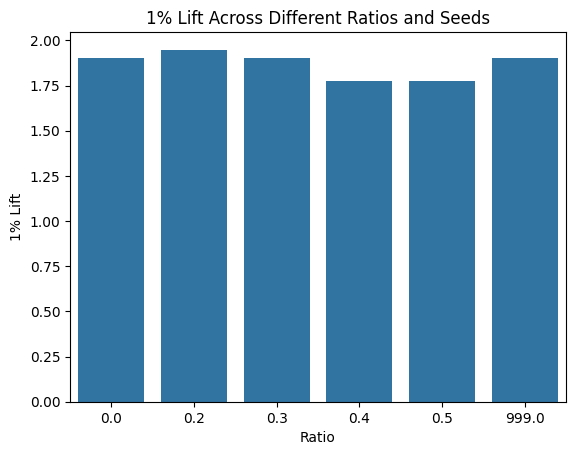

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=results_df, x='Ratio', y='1% Lift')
plt.title('1% Lift Across Different Ratios and Seeds')
plt.show()

results_df.to_csv('lift_results.csv', index=False)

In [66]:
def check_label_distribution(y):
    # Count the number of occurrences of each label 
    count_0 = (y == 0).sum()
    count_1 = (y == 1).sum()
    ratio = count_1 / count_0 if count_0 != 0 else np.inf
    print(count_0, count_1, ratio)
    return count_0, count_1, ratio

print("Training Set:")
check_label_distribution(y_train)

print("\nTest Set:")
check_label_distribution(y_test)

Training Set:
903 97 0.10741971207087486

Test Set:
934 66 0.07066381156316917


(np.int64(934), np.int64(66), np.float64(0.07066381156316917))

In [7]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

2025-10-15 14:25:41.637691: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-15 14:25:41.725190: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/opt/conda/lib/python3.10/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at te

Num GPUs Available:  0


2025-10-15 14:25:57.399395: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [9]:
!pip uninstall tensorflow -y

Found existing installation: tensorflow 2.20.0
Uninstalling tensorflow-2.20.0:
  Successfully uninstalled tensorflow-2.20.0


In [67]:
import gc
from xgboost import XGBClassifier
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold

# Check if GPU is available

#gpus = tf.config.experimental.list_physical_devices('GPU')
#if not gpus:
#    raise SystemError("No GPUs found. Please ensure your environment has a GPU available.")

# Initialize the GPU-enabled XGBoost classifier
xgb_model_rfe = XGBClassifier(
    random_state=53,
    n_jobs=-1,
    verbosity=0,
    use_label_encoder=False,
    tree_method = "hist", 
    device = "cuda"
)

rfecv = RFECV(
    estimator=xgb_model_rfe,
    step=10,
    cv=StratifiedKFold(3),
    scoring="roc_auc",
    min_features_to_select=1,
    n_jobs=-1
)

rfecv.fit(X_train, y_train)

print(f"Optimal number of features: {rfecv.n_features_}")

X_train_selected = rfecv.transform(X_train)
X_test_selected = rfecv.transform(X_test)

# Clear memory after fitting
gc.collect()

Optimal number of features: 98


548

In [68]:
selected_features_mask = rfecv.support_

# If you have feature names (column names), you can get them like this:
# Assuming your original features are in a DataFrame or have column names
selected_feature_names = X_test.columns[selected_features_mask]
print("Selected features:")
print(len(selected_feature_names.tolist()))

Selected features:
98


In [69]:

X_train_df = pd.DataFrame(X_train, columns = df.columns)
selected_features = X_train.columns[rfecv.support_]
print(selected_features)
print(len(selected_features))
with open('gdm_selected_features.txt', 'w') as file:
    # Join the list elements into a single string with a newline character
    data_to_write = '\n'.join(selected_features)
     
    # Write the data to the file
    file.write(data_to_write)

Index(['asdb_member_key', 'gest_age', 'mom_age', 'obesity', 'pcos',
       'bleeding_in_current_preg', 'nicu_lvl', 'lab_hba1c_current',
       'lab_glucose_current', 'glucose_challenge_current', 'lab_creat',
       'lab_altsgpt', 'lab_ferritin', 'emis_lab_clm_yr1', 'emis_ambul_clm_yr1',
       'coe_eval_clm_yr1', 'uc_clm_yr1', 'days_supply_sum_yr1',
       'retail_fills_yr1', 'agenbr', 'tenure_yr2', 'post_mnths',
       'acs_social_risk_score', 'sdi_score', 'adi_score', 'citizenship_index',
       'food_access', 'health_access', 'health_habits', 'housing_desert',
       'housing_quality', 'income_index', 'income_inequality', 'poverty_score',
       'proactive_health', 'racial_diversity', 'social_isolation',
       'technology_access', 'transport_access', 'unemployment_index',
       'water_quality', 'disability_score', 'health_infra',
       'csdi_social_risk_score', 'sum_spec', 'emb8', 'emb15', 'emb20', 'emb35',
       'emb40', 'emb46', 'emb52', 'emb53', 'emb64', 'emb66', 'emb70', 'em

In [ ]:
from google.cloud import storage

# Upload the file to your bucket
def upload_to_gcs(bucket_name, source_file_name, destination_blob_name):
    """Uploads a file to the bucket."""
    storage_client = storage.Client()
    bucket = storage_client.bucket(bucket_name)
    blob = bucket.blob(destination_blob_name)
    
    blob.upload_from_filename(source_file_name)
    print(f"File {source_file_name} uploaded to {destination_blob_name}")

# Use it after creating the file
bucket_name = "hcm-cm-de-code-hcb-dev"
destination_path = "vertex-test/codecode/gdm_selected_features.txt"

upload_to_gcs(bucket_name, "gdm_selected_features.txt", destination_path)



File gdm_selected_features.txt uploaded to vertex-test/gdm_selected_features.txt


Selected 98 features
Original training data shape: (1000, 619)
Selected training data shape: (1000, 99)


C:\Users\A974930\AppData\Local\Temp\ipykernel_24732\1366030356.py:2: FutureWarning: to_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.to_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.to_gbq
  train_df_selected.to_gbq(
100%|██████████| 1/1 [00:00<00:00, 1204.57it/s]


Successfully uploaded selected features to anbc-hcb-dev.cm_medicaid_hcb_dev.a974930_sahil_test_selected_features_train
✅ Added labels and 7-day expiry to anbc-hcb-dev.cm_medicaid_hcb_dev.a974930_sahil_test_selected_features_train
